<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDS0321ENSkillsNetwork26802033-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Space X  Falcon 9 First Stage Landing Prediction**


## Hands on Lab: Complete the Machine Learning Prediction lab


Estimated time needed: **60** minutes


Space X advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is because Space X can reuse the first stage. Therefore if we can determine if the first stage will land, we can determine the cost of a launch. This information can be used if an alternate company wants to bid against space X for a rocket launch.   In this lab, you will create a machine learning pipeline  to predict if the first stage will land given the data from the preceding labs.


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)


Several examples of an unsuccessful landing are shown here:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


Most unsuccessful landings are planed. Space X; performs a controlled landing in the oceans.


## Objectives


Perform Exploratory Data Analysis and determine Training Labels.

*   Create a column for the class
*   Standardize the data
*   Split data into training data and test data
*   Find the best Hyperparameters for SVM, Classification Trees, and Logistic Regression
*   Find the model that performs the best using the test data

## Import Libraries and Define Auxiliary Functions


In [1]:
# Installing needed libraries

#import piplite
#await piplite.install(['numpy'])
#await piplite.install(['pandas'])
#await piplite.install(['seaborn'])

We will import the following libraries for the project.

In [2]:
# Importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import tree
from packaging import version

This function will be used to plot the confusion matrix.

In [3]:
# Function to plot the confusion matrix

from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y, y_predict):
    cm = confusion_matrix(y, y_predict)
    ax = plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax); # annot=True to annotate cells
    ax.set_xlabel('Predicted Labels')
    ax.set_ylabel('True Labels')
    ax.set_title('Confusion Matrix'); 
    ax.xaxis.set_ticklabels(['did not land', 'land']); 
    ax.yaxis.set_ticklabels(['did not land', 'landed']) 
    plt.show() 

## Load the Dataframe

In [4]:
# Loading the data from part 2

#from js import fetch
#import io

URL1 = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
#resp1 = await fetch(URL1)
#text1 = io.BytesIO((await resp1.arrayBuffer()).to_py())
#data = pd.read_csv(text1)

data = pd.read_csv(URL1)

In [5]:
# Showing the first records of the dataset

data.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [6]:
# Saving dataset locally

#data.to_csv('initial_dataset_part_2.csv')

In [7]:
# Loading the data from part 3

URL2 = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv'
#resp2 = await fetch(URL2)
#text2 = io.BytesIO((await resp2.arrayBuffer()).to_py())
#X = pd.read_csv(text2)

X = pd.read_csv(URL2)

In [8]:
# Showing the first records of the dataset

X.head(100)

,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,...,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062,GridFins_False,GridFins_True,Reused_False,Reused_True,Legs_False,Legs_True
0,1.0,6104.959412,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,2.0,525.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,3.0,677.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,4.0,500.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,5.0,3170.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,86.0,15400.000000,2.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
86,87.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
87,88.0,15400.000000,6.0,5.0,5.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
88,89.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0


In [9]:
# Saving dataset locally

#X.to_csv('initial_dataset_part_3.csv')

## TASK  1


Create a NumPy array from the column <code>Class</code> in <code>data</code>, by applying the method <code>to_numpy()</code>  then
assign it  to the variable <code>Y</code>,make sure the output is a  Pandas series (only one bracket df\['name of  column']).


In [10]:
# Creating a NumPy array from the column Class in dataframe data

Y = data['Class'].to_numpy()

In [11]:
# Showing the shape of Y

Y.shape

(90,)

## TASK  2


Standardize the data in <code>X</code> then reassign it to the variable  <code>X</code> using the transform provided below.


In [12]:
# Standardizing features

feature_names = X.columns.to_list()
transform = preprocessing.StandardScaler()
scaled_features = transform.fit_transform(X[feature_names]) # All columns of X are of type float so the argument could be X alone
X = pd.DataFrame(scaled_features, columns=transform.get_feature_names_out(feature_names))
print(X.shape)
X.head(10)

(90, 83)


,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,...,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062,GridFins_False,GridFins_True,Reused_False,Reused_True,Legs_False,Legs_True
0,-1.712912,-1.948145e-16,-0.653913,-1.575895,-0.97344,-0.106,-0.106,-0.654654,-0.106,-0.551677,...,-0.185695,-0.215666,-0.185695,-0.106,1.870829,-1.870829,0.835532,-0.835532,1.933091,-1.933091
1,-1.674419,-1.195232e+00,-0.653913,-1.575895,-0.97344,-0.106,-0.106,-0.654654,-0.106,-0.551677,...,-0.185695,-0.215666,-0.185695,-0.106,1.870829,-1.870829,0.835532,-0.835532,1.933091,-1.933091
2,-1.635927,-1.162673e+00,-0.653913,-1.575895,-0.97344,-0.106,-0.106,-0.654654,-0.106,1.812654,...,-0.185695,-0.215666,-0.185695,-0.106,1.870829,-1.870829,0.835532,-0.835532,1.933091,-1.933091
3,-1.597434,-1.200587e+00,-0.653913,-1.575895,-0.97344,-0.106,-0.106,-0.654654,-0.106,-0.551677,...,-0.185695,-0.215666,-0.185695,-0.106,1.870829,-1.870829,0.835532,-0.835532,1.933091,-1.933091
4,-1.558942,-6.286706e-01,-0.653913,-1.575895,-0.97344,-0.106,-0.106,1.527525,-0.106,-0.551677,...,-0.185695,-0.215666,-0.185695,-0.106,1.870829,-1.870829,0.835532,-0.835532,1.933091,-1.933091
5,-1.520450,-5.954694e-01,-0.653913,-1.575895,-0.97344,-0.106,-0.106,1.527525,-0.106,-0.551677,...,-0.185695,-0.215666,-0.185695,-0.106,1.870829,-1.870829,0.835532,-0.835532,1.933091,-1.933091
6,-1.481957,-8.158820e-01,-0.653913,-1.575895,-0.97344,-0.106,-0.106,-0.654654,-0.106,1.812654,...,-0.185695,-0.215666,-0.185695,-0.106,1.870829,-1.870829,0.835532,-0.835532,-0.517306,0.517306
7,-1.443465,-1.025799e+00,-0.653913,-1.575895,-0.97344,-0.106,-0.106,-0.654654,-0.106,-0.551677,...,-0.185695,-0.215666,-0.185695,-0.106,1.870829,-1.870829,0.835532,-0.835532,-0.517306,0.517306
8,-1.404972,-3.362865e-01,-0.653913,-1.575895,-0.97344,-0.106,-0.106,1.527525,-0.106,-0.551677,...,-0.185695,-0.215666,-0.185695,-0.106,1.870829,-1.870829,0.835532,-0.835532,1.933091,-1.933091
9,-1.366480,-3.592060e-01,-0.653913,-1.575895,-0.97344,-0.106,-0.106,1.527525,-0.106,-0.551677,...,-0.185695,-0.215666,-0.185695,-0.106,1.870829,-1.870829,0.835532,-0.835532,1.933091,-1.933091


We will split the data into training and testing data using the function <code>train_test_split</code>. The training data is divided into validation data, a second set used for training data; then the models are trained and hyperparameters are selected using the function <code>GridSearchCV</code>.

## TASK  3


Use the function train_test_split to split the data X and Y into training and test data. Set the parameter test_size to  0.2 and random_state to 2. The training data and test data should be assigned to the following labels.


<code>X_train, X_test, Y_train, Y_test</code>

In [13]:
# Splitting the data into training and test data sets

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

we can see we only have 18 test samples.


In [14]:
# Checking the shape of Y_test

Y_test.shape

(18,)

## TASK  4


Create a logistic regression object  then create a  GridSearchCV object  <code>logreg_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.

In [15]:
# Parameters to be used with the Logistic Regression model

if version.parse(sklearn.__version__) >= version.parse("1.8"):
    lr_parameters = {
                    'C' : [0.01, 0.1, 1],
                    'l1_ratio' : [0],    # 0 = l2 ridge
                    'solver' : ['lbfgs']
    }
else:
    lr_parameters = {
                    'C' : [0.01, 0.1, 1],
                    'penalty' : ['l2'],    # l1 lasso; l2 ridge
                    'solver' : ['lbfgs']
    }

In [16]:
# Prepare the Logistic Regression model using the already defined parameters, cv = 10, and then fit the model

# Creating a Logistic Regression object
# And fixing model for reproducibility
lr = LogisticRegression(random_state=1)

# Creating a Grid Search object
logreg_cv = GridSearchCV(lr, lr_parameters, cv=10)

# Fit the model
logreg_cv.fit(X_train, Y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...andom_state=1)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'l1_ratio': [0], 'solver': ['lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;

We output the <code>GridSearchCV</code> object for logistic regression. We display the best parameters using the data attribute <code>best_params\_</code> and the accuracy on the validation data using the data attribute <code>best_score\_</code>.


In [17]:
# Getting the best parameters for the logistic regression and the accuracy using the validation data

lr_accuracy = round(logreg_cv.best_score_, 2)
print("Tuned hpyerparameters (best parameters): ", logreg_cv.best_params_)
print("Accuracy: ", lr_accuracy)

Tuned hpyerparameters (best parameters):  {'C': 0.01, 'l1_ratio': 0, 'solver': 'lbfgs'}
Accuracy:  0.85


## TASK  5


Calculate the accuracy on the test data using the method <code>score</code>:


In [18]:
# Calculating the accuracy on the test data using the method score

# Getting the score
lr_score = round(logreg_cv.score(X_test, Y_test), 2)
print("The score for the Logistic Regression model is: ", lr_score)

The score for the Logistic Regression model is:  0.83


Lets look at the confusion matrix:


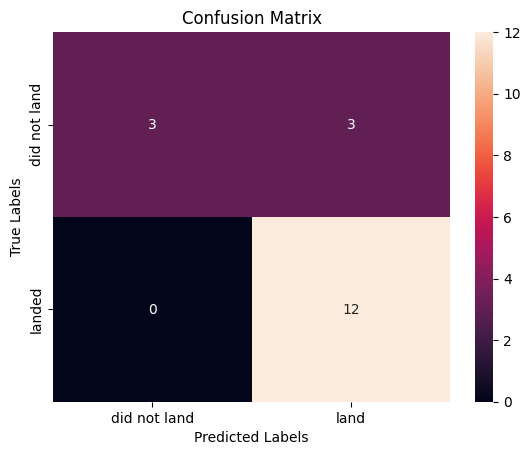

In [19]:
# Generating the confusion matrix for the Logistic Regression model

lr_yhat = logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test, lr_yhat)

Examining the confusion matrix, we see that logistic regression can distinguish between the different classes.  We see that the problem is false positives.

Overview:

True Postive - 12 (True label is landed, Predicted label is also landed)

False Postive - 3 (True label is not landed, Predicted label is landed)


## TASK  6


Create a support vector machine object then  create a  <code>GridSearchCV</code> object  <code>svm_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [20]:
# Creating parameters for SVM and an instance of SVC

svm_parameters = {'kernel' : ('linear', 'rbf', 'poly', 'rbf', 'sigmoid'),
                 'C' : np.logspace(-3, 3, 5),
                 'gamma' : np.logspace(-3, 3, 5)}

# Fixing model for reproducibility
svm = SVC(random_state=1)

In [21]:
# Prepare the SVM model using the already defined parameters, cv = 10, and then fit the model

# Creating a Grid Search object
svm_cv = GridSearchCV(svm, svm_parameters, cv=10)

# Fit the model
print('Fitting model started')
svm_cv.fit(X_train, Y_train)
print('Fitting model ended')

Fitting model started
Fitting model ended


In [22]:
# Getting the best parameters for the SVM model and the accuracy using the validation data

svm_accuracy = round(svm_cv.best_score_, 2)
print("Tuned hpyerparameters (best parameters): ", svm_cv.best_params_)
print("Accuracy: ", svm_accuracy)

Tuned hpyerparameters (best parameters):  {'C': np.float64(1.0), 'gamma': np.float64(0.03162277660168379), 'kernel': 'sigmoid'}
Accuracy:  0.85


## TASK  7


Calculate the accuracy on the test data using the method <code>score</code>:


In [23]:
# Calculating the accuracy on the test data using the method score

# Getting the score
svm_score = round(svm_cv.score(X_test, Y_test), 2)
print("The score for the SVM model is: ", svm_score)

The score for the SVM model is:  0.83


We can plot the confusion matrix


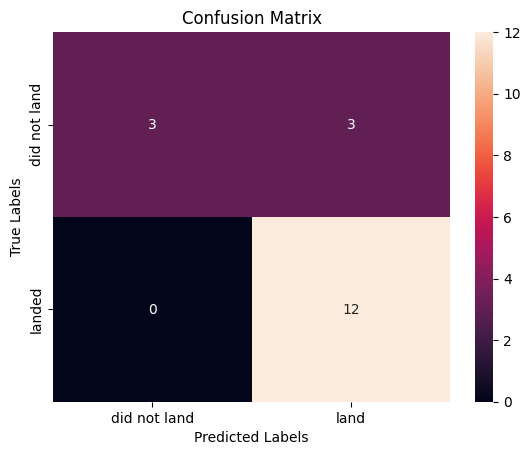

In [24]:
# Generating the confusion matrix for the SVM model

svm_yhat = svm_cv.predict(X_test)
plot_confusion_matrix(Y_test, svm_yhat)

## TASK  8


Create a decision tree classifier object then  create a  <code>GridSearchCV</code> object  <code>tree_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [25]:
# Creating parameters for tree model and an instance of Decision Tree Classifier

tree_parameters = {'criterion': ['gini', 'entropy'],
                  'splitter': ['best', 'random'],
                  'max_depth': [2*n for n in range(1, 10)],
                  'max_features': ['log2', 'sqrt'],             # Replaced 'auto' with 'log2' as 'auto' is no longer supported 
                  'min_samples_leaf': [1, 2, 4],
                  'min_samples_split': [2, 5, 10]}

# Fixing model for reproducibility
tree = DecisionTreeClassifier(random_state=1)

In [26]:
# Prepare the tree model using the already defined parameters, cv = 10, and then fit the model

# Creating a Grid Search object
tree_cv = GridSearchCV(tree, tree_parameters, cv=10)

# Fit the model
print('Fitting model started')
tree_cv.fit(X_train, Y_train)
print('Fitting model ended')

Fitting model started
Fitting model ended


In [27]:
# Getting the best parameters for the decision tree model and the accuracy using the validation data

tree_accuracy = round(tree_cv.best_score_, 2)
print("Tuned hpyerparameters (best parameters): ", tree_cv.best_params_)
print("Accuracy: ", tree_accuracy)

Tuned hpyerparameters (best parameters):  {'criterion': 'gini', 'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'splitter': 'random'}
Accuracy:  0.84


## TASK  9


Calculate the accuracy of tree_cv on the test data using the method <code>score</code>:


In [28]:
# Calculating the accuracy on the test data using the method score

# Getting the score
tree_score = round(tree_cv.score(X_test, Y_test), 2)
print("The score for the tree model is: ", tree_score)

The score for the tree model is:  0.78


We can plot the confusion matrix


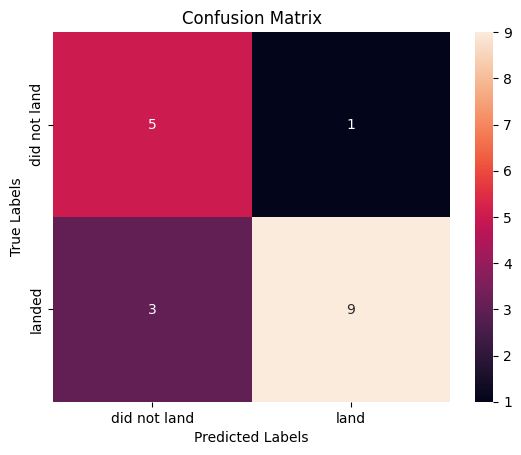

In [29]:
# Generating the confusion matrix for the tree model

tree_yhat = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test, tree_yhat)

## TASK  10


Create a k nearest neighbors object then  create a  <code>GridSearchCV</code> object  <code>knn_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [30]:
# Creating parameters for the KNN model and an instance of the Classifier

knn_parameters = {'n_neighbors' : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                 'algorithm' : ['auto', 'ball_tree', 'kd_tree', 'brute'],
                 'p' : [1, 2]}

KNN = KNeighborsClassifier()

In [31]:
# Prepare the KNN model using the already defined parameters, cv = 10, and then fit the model

# Creating a Grid Search object
knn_cv = GridSearchCV(KNN, knn_parameters, cv=10)

# Fit the model
print('Fitting model started')
knn_cv.fit(X_train, Y_train)
print('Fitting model ended')

Fitting model started
Fitting model ended


In [32]:
# Getting the best parameters for the KNN model and the accuracy using the validation data

knn_accuracy = round(knn_cv.best_score_, 2)
print("Tuned hpyerparameters (best parameters): ", knn_cv.best_params_)
print("Accuracy: ", knn_accuracy)

Tuned hpyerparameters (best parameters):  {'algorithm': 'auto', 'n_neighbors': 10, 'p': 1}
Accuracy:  0.85


## TASK  11


Calculate the accuracy of knn_cv on the test data using the method <code>score</code>:


In [33]:
# Calculating the accuracy on the test data using the method score

# Getting the score
knn_score = round(knn_cv.score(X_test, Y_test), 2)
print("The score for the KNN model is: ", knn_score)

The score for the KNN model is:  0.83


We can plot the confusion matrix


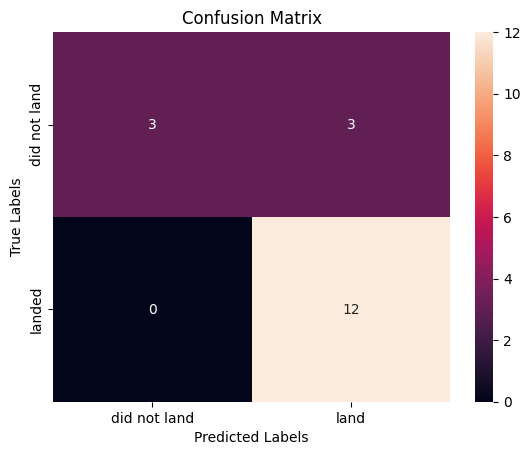

In [34]:
# Generating the confusion matrix for the KNN model

knn_yhat = knn_cv.predict(X_test)
plot_confusion_matrix(Y_test, knn_yhat)

## TASK  12


Find the method that performs best:


In [35]:
# Preparing data for summary table

summary_data = {
                'Model' : ['Logistic Regression', 'Support Vector Machines', 'Decision Tree', 'K-Nearest Neighbor'],
                'Accuracy' : [lr_accuracy, svm_accuracy, tree_accuracy, knn_accuracy],
                'Score' : [lr_score, svm_score, tree_score, knn_score]
}

summary_df = pd.DataFrame(summary_data)
summary_df.set_index('Model', inplace=True)

#### Showing a Summary Table for all Models

In [36]:
# Displaying the summary table

summary_df

,Accuracy,Score
Model,,
Logistic Regression,0.85,0.83
Support Vector Machines,0.85,0.83
Decision Tree,0.84,0.78
K-Nearest Neighbor,0.85,0.83


### Visualizing the Decision Tree for the Best Estimator

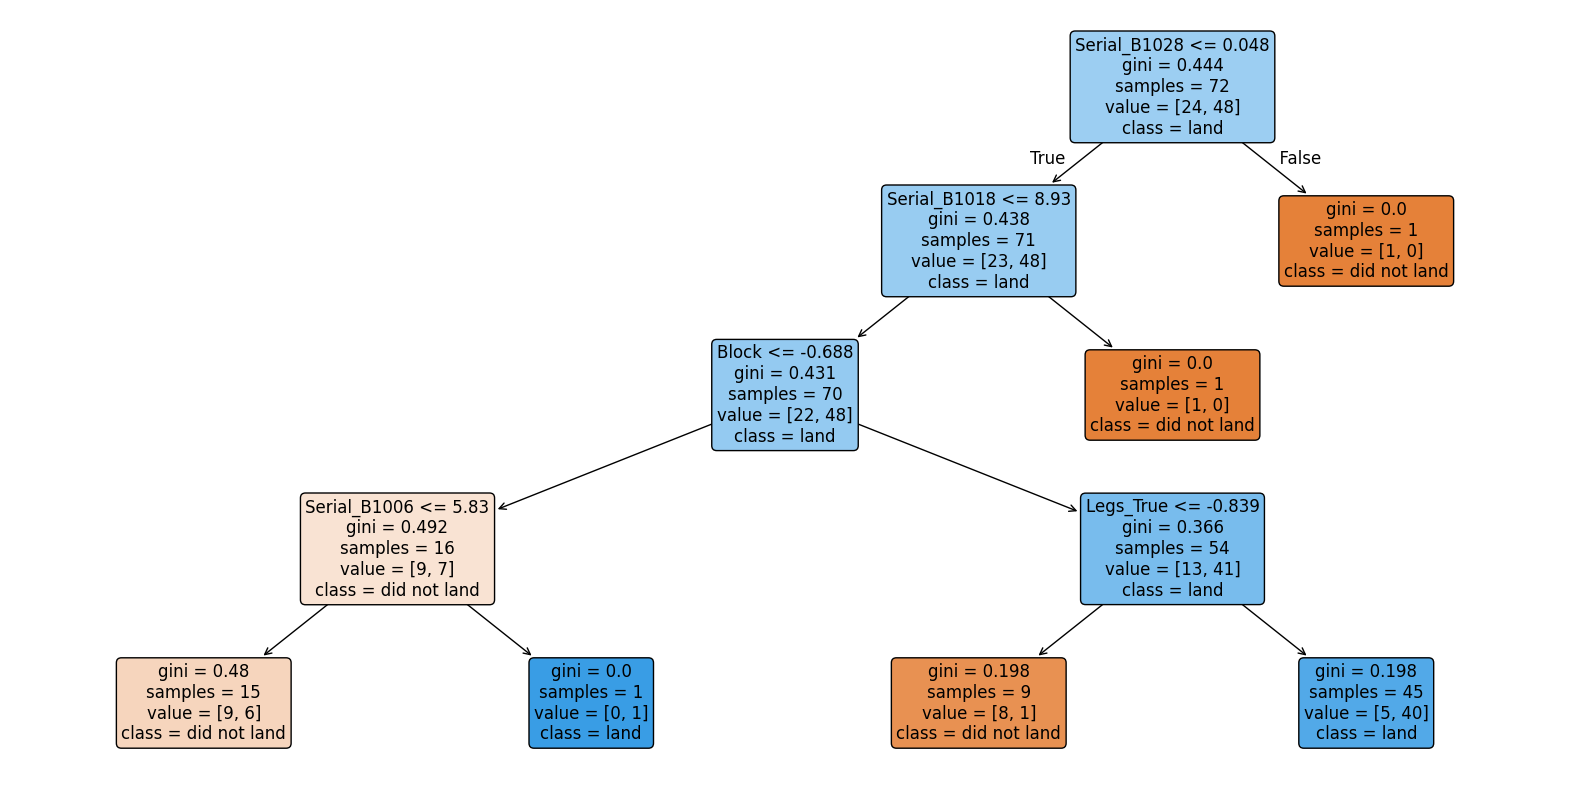

In [37]:
# Showing the decision tree for the best estimator

from sklearn import tree

plt.figure(figsize=(20,10))

# Plot the tree
tree.plot_tree(tree_cv.best_estimator_, 
               feature_names=X.columns.tolist(), 
               class_names=['did not land', 'land'], 
               filled=True, 
               rounded=True, 
               fontsize=12)

plt.show()

The visualization identifies the **Block** feature as the primary decision factor (root node), indicating it carries the highest predictive power for landing success. The nodes are color-coded by **Gini Impurity**: dark orange represents a high-certainty prediction of 'did not land,' while dark blue indicates a high-certainty prediction of 'landed.' The terminal 'leaf' nodes at the base represent the final classification outcomes for the test observations.

### Showing the Model Scores in a Bar Chart

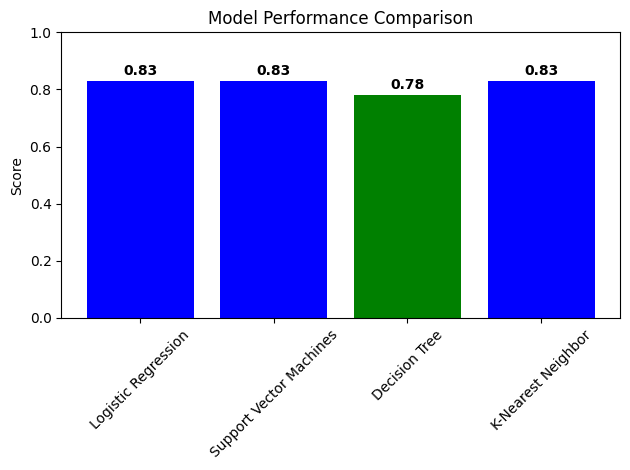

In [38]:
# Showing the model scores in a bar chart

plt.bar(summary_data['Model'], summary_data['Score'], color=['blue', 'blue', 'green', 'blue'])
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.ylim(0.0, 1.0) 
plt.xticks(rotation=45)
# Add annotations
for i, score in enumerate(summary_data['Score']):
    plt.text(i, score + 0.02, f'{score:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Model Comparison:** Logistic Regression, SVM, and K-Nearest Neighbor all achieved a score of **83%**, while the Decision Tree Classifier had a score of 78%.

### Final Conclusions and Model Selection

Before providing the conclusions and the selected model for this project, it is important to take into account the following considerations:

* Given the nature of the business case (the prediction of a successful first-stage rocket landing), there is little data available. We are aware that rocket launching is an expensive enterprise and it does not happen that often, resulting in the availability of few observations.
* For this phase of the project (building a predictor classifier) we only have 90 observations available. Using an 80/20 split of the data, we end up with only 18 observations for the test data.
* For the Decision Tree Classifier, we had to change one value of the **'max_features'** parameter as it was no longer supported by scikit-learn. We switched the value of **'auto'** to **'log2'**.
* After executing the models repeated times, the Decision Tree Classifier showed instability. Its score went from a minimum of 0.72 to a maximum of 0.94 (see images below) and several values in between. The other three models remained stable though.
* To allow reproducibility, the models for Logistic Regression, SVM, and Decision Tree were initialized with random_state=1.

<div style="display: flex; justify-content: space-around;">
    <img src="images/decision_tree_min_score.png" width="300" height="160">
    <img src="images/decision_tree_max_score.png" width="300" height="160">
</div>

#### Final Verdict

Based on the information gathered after training the four different models, we can clearly see that the Decision Tree Classifier model underperforms the other 3 models (Logistic Regression, Support Vector Machines, and K-Nearest Neighbor). The Summary Table shows that LR, SVM, and KNN have the same Accuracy (**0.85**) and Score (**0.83**). In contrast, the Decision Tree Classifier has lower Accuracy (0.84) and Score (0.78).

Furthermore, by analyzing the confusion matrices, the Logistic Regression, SVM, and KNN models have three false positives (predictions of successful landings that actually failed). The Decision Tree Classifier has 3 false negatives and one false positive. At the same time, it is worth mentioning that the Logistic REgression, SVM, and KNN models have no false negatives, meaning that any time the models predicted that a rocket booster would not land, in fact it did not land.

This project showed that the Decision Tree model can be sensitive to small datasets, as confirmed by the multiple executions performed before stabilizing the model that returned different scores. 

With all the abovementioned caveats, we conclude that for this project either **Logistic Regression**, or **Support Vector Machines**, or **K-Nearest Neighbor** can be better suited for this business case.

## Authors


[Pratiksha Verma](https://www.linkedin.com/in/pratiksha-verma-6487561b1/)


<!--## Change Log--!>


<!--| Date (YYYY-MM-DD) | Version | Changed By      | Change Description      |
| ----------------- | ------- | -------------   | ----------------------- |
| 2022-11-09        | 1.0     | Pratiksha Verma | Converted initial version to Jupyterlite|--!>


### <h3 align="center"> IBM Corporation 2022. All rights reserved. <h3/>
